In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import itertools

2026-08-31 09:32:37.470597: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-31 09:32:37.470706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-31 09:32:37.600736: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Constants
IMG_SIZE = 48
DATA_DIR = '/kaggle/input/facial-emotion-recognition/images'
EMOTIONS = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']

# Load the dataset
csv_path = '/kaggle/input/facial-emotion-recognition/emotions.csv'
emotions_df = pd.read_csv(csv_path)

In [3]:
emotions_df['set_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18])

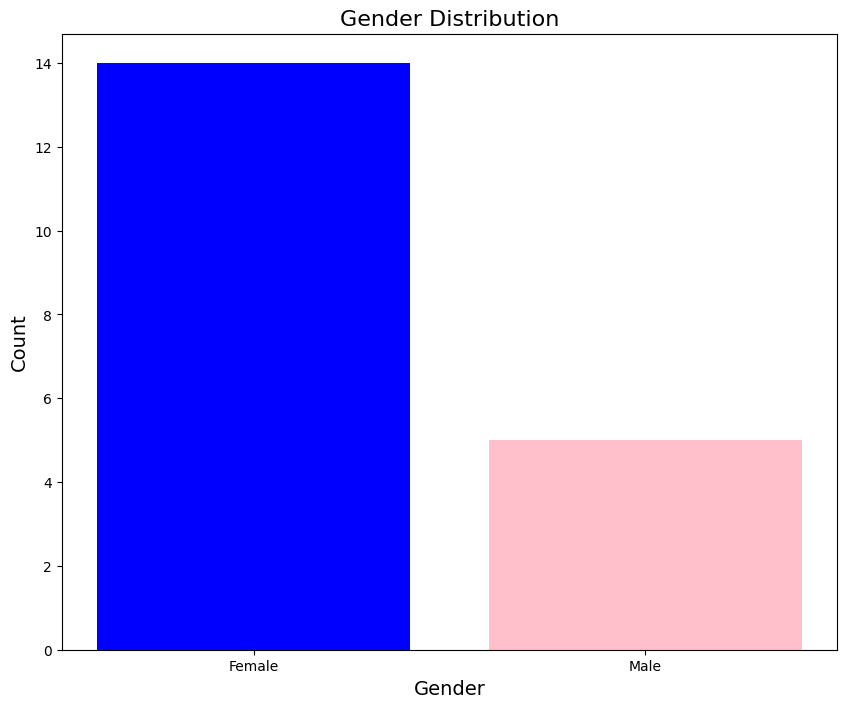

In [4]:
# Gender distribution
plt.figure(figsize=(10, 8))
gender_counts = emotions_df['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

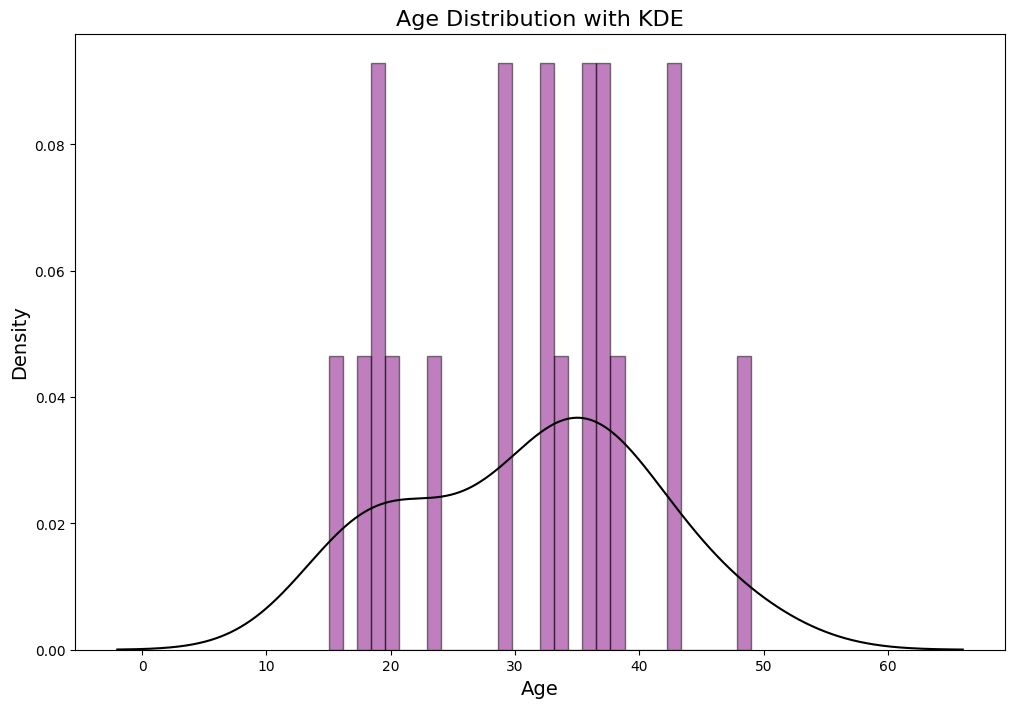

In [5]:
# Age distribution with KDE
plt.figure(figsize=(12, 8))
emotions_df['age'].plot(kind='hist', bins=30, density=True, alpha=0.5, color='purple', edgecolor='black')
emotions_df['age'].plot(kind='kde', color='black')
plt.title('Age Distribution with KDE', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.show()

<Figure size 1000x800 with 0 Axes>

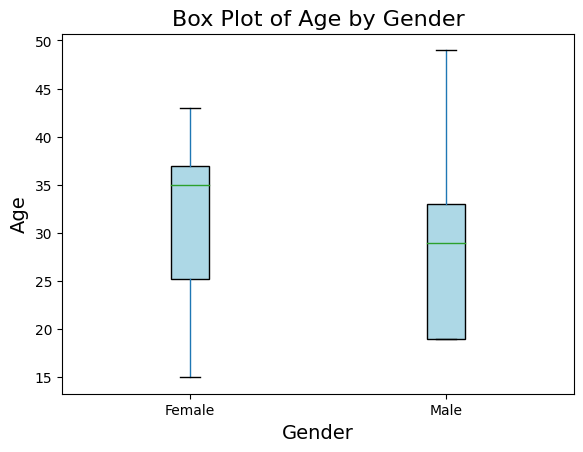

In [6]:
# Box plot of age by gender
plt.figure(figsize=(10, 8))
emotions_df.boxplot(column='age', by='gender', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Age by Gender', fontsize=16)
plt.suptitle('')
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.xticks([1, 2], ['Female', 'Male'])
plt.show()

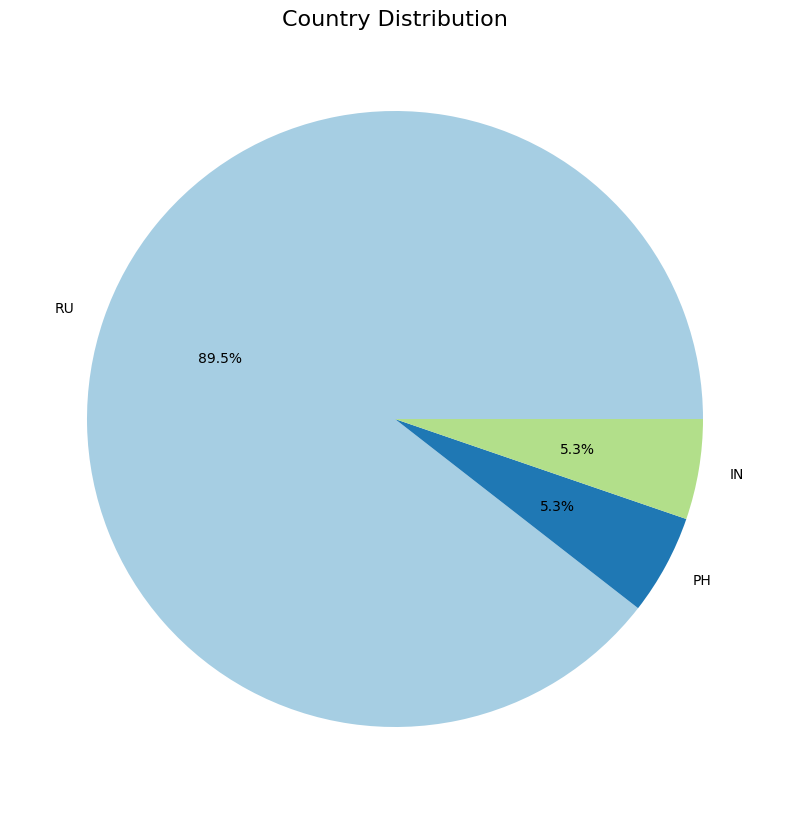

In [7]:
# Pie chart for country distribution
country_counts = emotions_df['country'].value_counts()
plt.figure(figsize=(12, 10))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired(np.arange(len(country_counts))))
plt.title('Country Distribution', fontsize=16)
plt.show()

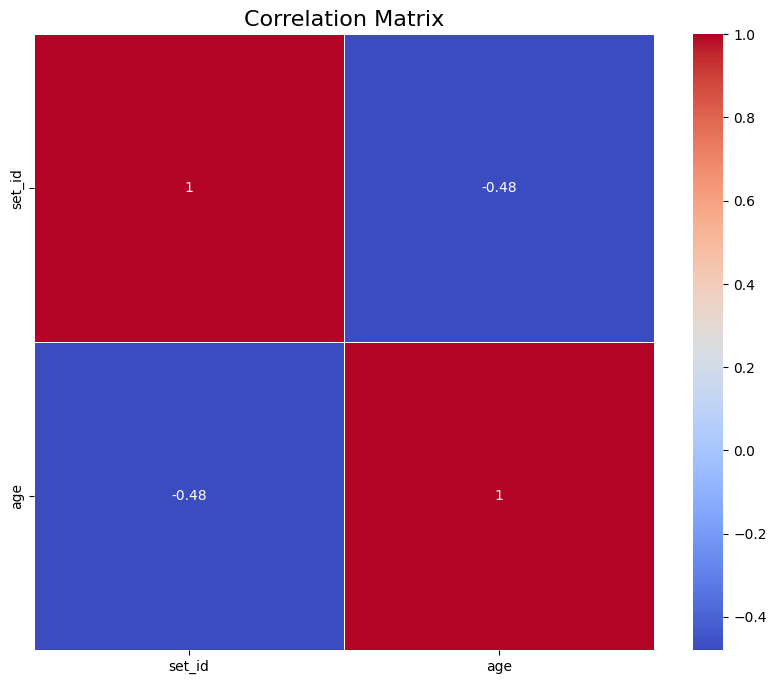

In [8]:
plt.figure(figsize=(10, 8))
numeric_cols = emotions_df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [9]:
# Encode the gender column
label_encoder = LabelEncoder()
emotions_df['gender'] = label_encoder.fit_transform(emotions_df['gender'])

In [10]:
# Function to load and preprocess images
def load_data():
    images = []
    labels = []
    
    for emotion_label, emotion in enumerate(EMOTIONS):
        # Get the directory for the current emotion
        emotion_dir = os.path.join(DATA_DIR, str(emotion_label))
        if os.path.isdir(emotion_dir):
            for img_file in os.listdir(emotion_dir):
                img_path = os.path.join(emotion_dir, img_file)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                images.append(img_resized)
                labels.append(emotion_label)  # Assigning label based on index
        else:
            print(f"Directory not found for emotion {emotion}: {emotion_dir}")
        
    return np.array(images), np.array(labels)

# Load the data
images, labels = load_data()

In [11]:
# Normalize images
images = images / 255.0

# Encode labels to categorical
labels_categorical = to_categorical(labels, num_classes=len(EMOTIONS))

In [12]:
# Check the distribution of the labels to ensure balance
print("Distribution of emotions:")
print(pd.Series(labels).value_counts())

Distribution of emotions:
0    8
1    8
2    8
3    8
4    8
5    8
6    8
7    8
Name: count, dtype: int64


In [13]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

In [14]:
# Reshape for the model
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [15]:
# Model Training
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(EMOTIONS), activation='softmax')  # Ensure the correct number of classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


2026-08-31 09:32:56.667751: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 4.07344, expected 3.39204
2026-08-31 09:32:56.667805: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 3.66488, expected 2.98347
2026-08-31 09:32:56.667814: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 3.34272, expected 2.66131
2026-08-31 09:32:56.667821: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 3.82969, expected 3.14828
2026-08-31 09:32:56.667829: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 3.0197, expected 2.33829
2026-08-31 09:32:56.667836: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 2.8467, expected 2.16529
2026-08-31 09:32:56.667843: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 3.47484, expected 2.79343
2026-08-31 09:32:56.667850: E external/local_xla/xla/serv

1/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0625 - loss: 2.0687

I0000 00:00:1788168779.029633     107 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1788168779.046760     107 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
2026-08-31 09:32:59.722993: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 10: 1.56166, expected 1.27839
2026-08-31 09:32:59.723091: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 12: 1.64241, expected 1.35914
2026-08-31 09:32:59.723108: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 31: 1.69719, expected 1.41392
2026-08-31 09:32:59.723132: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 54: 1.81832, expected 1.53505
2026-08-31 09:32:59.723143: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 81: 1.80432, expected 1.52106
2026-08-31 09:32:59.723153: E external/

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0999 - loss: 2.0658

2026-08-31 09:33:02.243106: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2116: 3.2693, expected 2.35357
2026-08-31 09:33:02.243164: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2117: 2.94205, expected 2.02631
2026-08-31 09:33:02.243174: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2118: 3.30363, expected 2.3879
2026-08-31 09:33:02.243181: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2119: 3.37876, expected 2.46302
2026-08-31 09:33:02.243189: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2120: 2.38085, expected 1.46511
2026-08-31 09:33:02.243196: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2121: 2.83428, expected 1.91855
2026-08-31 09:33:02.243203: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2122: 3.02836, expected 2.11263
2026-08-31 09:33:02.243210: E extern

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.1123 - loss: 2.0648 - val_accuracy: 0.1538 - val_loss: 2.1140
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1332 - loss: 2.0844 - val_accuracy: 0.2308 - val_loss: 2.0899
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1906 - loss: 2.0658 - val_accuracy: 0.2308 - val_loss: 1.9597
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1906 - loss: 2.0477 - val_accuracy: 0.3077 - val_loss: 1.9253
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1828 - loss: 2.0373 - val_accuracy: 0.2308 - val_loss: 1.9252
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1959 - loss: 1.9880 - val_accuracy: 0.2308 - val_loss: 1.9180
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3002 - loss: 1.9069 - val_accuracy: 0.2308 - val_loss: 1.8830
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3342 - loss: 1.8344 - val_accuracy: 0.3846 - val_loss: 1.7798
Epoch 9/20
2/

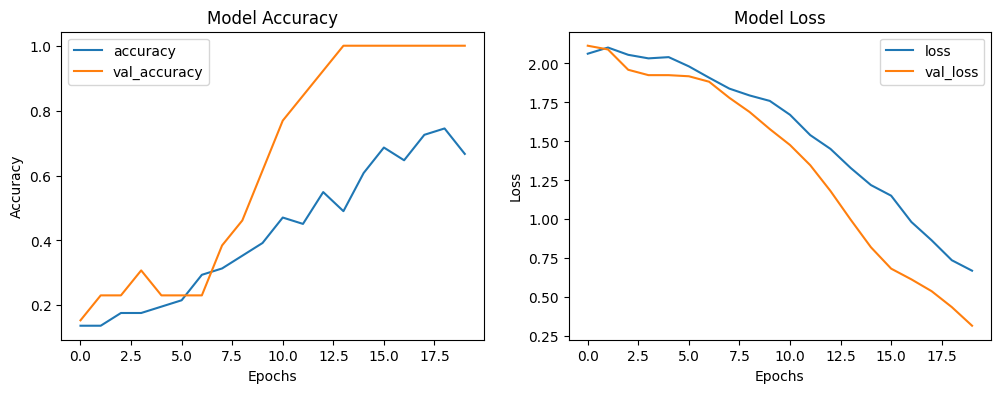

In [16]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


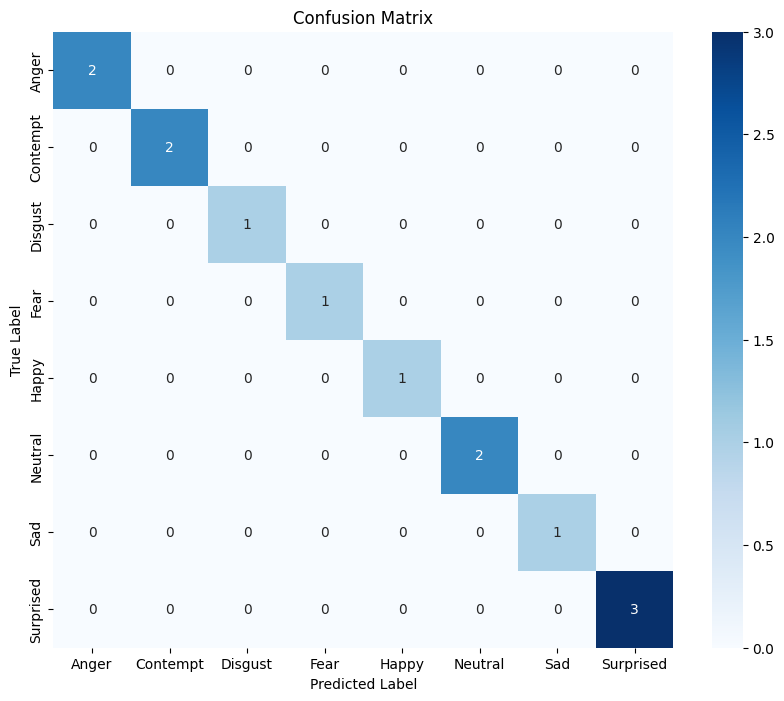

              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         2
    Contempt       1.00      1.00      1.00         2
     Disgust       1.00      1.00      1.00         1
        Fear       1.00      1.00      1.00         1
       Happy       1.00      1.00      1.00         1
     Neutral       1.00      1.00      1.00         2
         Sad       1.00      1.00      1.00         1
   Surprised       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [17]:
# Model Evaluation
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=EMOTIONS)
print(report)

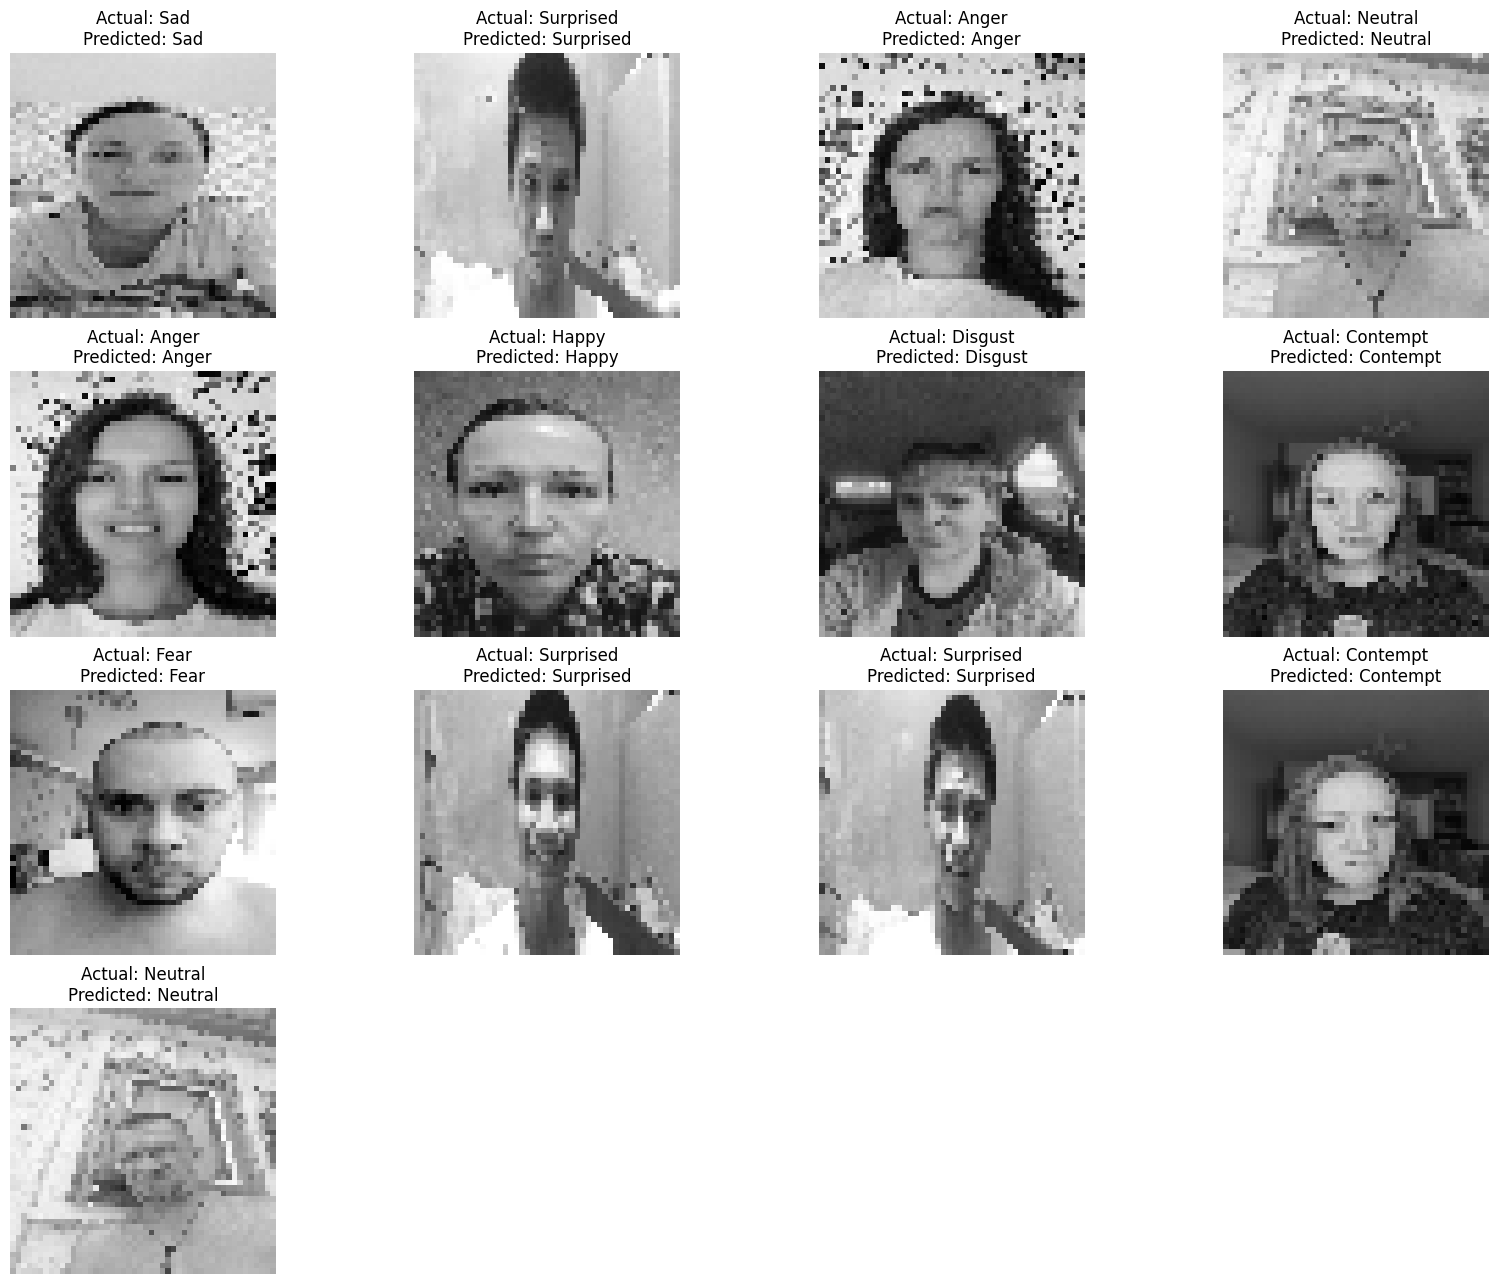

In [20]:
# Display images with predicted and actual labels
num_images = min(20, len(X_test))
plt.figure(figsize=(20, 20))
for i in range(num_images):
    plt.subplot(5, 4, i + 1)
    img = (X_test[i] * 255).astype(np.uint8)  # Convert back to uint8
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title(f"Actual: {EMOTIONS[y_true[i]]}\nPredicted: {EMOTIONS[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()